# Module 17 — Reasoning and GRPO

A CPU-only tour of the new pieces this module introduces:

1. The verifiable reward function (`rewards.py`).
2. Group-relative advantage estimation — the "GR" in GRPO.
3. The GRPO loss with PPO clip + per-token KL.
4. End-to-end on a tiny Qwen3: real `model.generate` + reward + loss + backward.
5. Memory accounting for the 1.7B canonical run.

Runs in CPU minutes. No real Qwen3 weights, no GSM8K download, no network.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

from config import TrainConfig, RewardConfig, RLConfig, DataConfig
cfg = TrainConfig()
cfg.sync()

print(f'policy:    {cfg.model.name}')
print(f'reference: {cfg.model.resolved_ref_name()} (same -> frozen copy of policy)')
print(f'data:      {cfg.data.source}/{cfg.data.subset}  split={cfg.data.split}')
print(f'rl:        G={cfg.rl.group_size}  T={cfg.rl.temperature}  '
      f'max_new={cfg.rl.max_new_tokens}  kl_beta={cfg.rl.kl_beta}  '
      f'clip_ratio={cfg.rl.clip_ratio}  mu_epochs={cfg.rl.mu_epochs}')
print(f'reward:    w_format={cfg.reward.w_format}  w_accuracy={cfg.reward.w_accuracy}')
print(f'optimizer: lr={cfg.optimizer.lr}  (~2x DPO, ~10x lower than SFT)')
print(f'training:  total_steps={cfg.training.total_steps}  AC={cfg.training.activation_checkpointing}')

policy:    Qwen/Qwen3-1.7B
reference: Qwen/Qwen3-1.7B (same -> frozen copy of policy)
data:      openai/gsm8k/main  split=train
rl:        G=8  T=0.9  max_new=512  kl_beta=0.04  clip_ratio=0.2  mu_epochs=1
reward:    w_format=0.1  w_accuracy=1.0
optimizer: lr=1e-06  (~2x DPO, ~10x lower than SFT)
training:  total_steps=300  AC=True


## 1. The verifier

The whole GRPO setup hinges on a function that takes (completion_text, ground_truth) and returns a scalar reward. For GSM8K it's two terms summed:

- **Format reward** (`w_format=0.1`): 1.0 if the response matches `<think>...</think><answer>...</answer>`, else 0.
- **Accuracy reward** (`w_accuracy=1.0`): 1.0 if the integer parsed from the LAST `<answer>...</answer>` block equals ground truth, else 0.

The format term is a "training wheels" bonus — it gives the policy a non-zero signal before it can solve any problems. By mid-training the accuracy term dominates.

In [2]:
from rewards import compute_rewards

cases = [
    ('schema OK + correct',  '<think>2+2=4</think><answer>4</answer>',     4),
    ('no schema + correct',  'The answer is 4 eggs.',                       4),
    ('schema OK + wrong',    '<think>nonsense</think><answer>7</answer>',   4),
    ('revised final answer', '<think>maybe 3? <answer>3</answer> wait, actually</think><answer>4</answer>', 4),
    ('parses commas + $',    '<think>x</think><answer>$1,234</answer>',  1234),
    ('garbage',              'banana',                                       4),
]

rcfg = RewardConfig()
brs = compute_rewards([t for _, t, _ in cases], [g for _, _, g in cases], rcfg)

print(f'{"case":<24} {"format":>7} {"acc":>5} {"total":>7}')
print('-' * 50)
for (label, _, _), br in zip(cases, brs):
    print(f'  {label:<22} {br.format:>7.1f} {br.accuracy:>5.1f} {br.total:>7.3f}')

case                      format   acc   total
--------------------------------------------------
  schema OK + correct        1.0   1.0   1.100
  no schema + correct        0.0   0.0   0.000
  schema OK + wrong          1.0   0.0   0.100
  revised final answer       1.0   1.0   1.100
  parses commas + $          1.0   1.0   1.100
  garbage                    0.0   0.0   0.000


Three principles for verifiers, painfully learned:

1. **Make it strict.** Tolerances get gamed.
2. **Verify outcomes, not traces.** Rewarding "looks-like-reasoning" produces traces that look right but are wrong. R1 verified only the final answer.
3. **Reward sparsity is OK. Reward gaming is fatal.** If the model finds a degenerate response (e.g. always emit `<answer>42</answer>`), make the verifier stricter, never softer.

## 2. Group-relative advantages

For each prompt, sample G completions, score each, then standardize within the group:

$$A_i = \frac{r_i - \bar{r}_{group}}{\sigma_{group} + \epsilon}$$

This is the variance-reduction trick that replaces PPO's value head. The within-group mean reward is a perfectly good baseline; no critic network to train.

Edge case: if all G rewards in a group are identical (very common when ALL miss the format or accuracy), `std=0` and every advantage in that group is 0 → that group contributes ZERO policy gradient. The policy gets no signal from groups where it can't tell which response is better, which is exactly correct.

In [3]:
from rollout import group_normalize_advantages

# 3 prompts, G=4 each. Construct rewards to illustrate three regimes.
rewards_flat = torch.tensor([
    1.1, 1.0, 0.1, 0.0,    # prompt 0: spread across 4 reward levels
    0.0, 0.0, 0.0, 0.0,    # prompt 1: degenerate — all G miss
    1.1, 1.0, 1.1, 1.1,    # prompt 2: nearly all hit; one slightly worse
])
G = 4
adv = group_normalize_advantages(rewards_flat, group_size=G, eps=1e-6)

print(f'{"prompt":<8} {"rewards":<25} {"-> advantages":<35}')
print('-' * 70)
for p in range(3):
    r = rewards_flat[p*G:(p+1)*G].tolist()
    a = adv[p*G:(p+1)*G].tolist()
    print(f'  p{p:<6}  {[round(x,2) for x in r]!s:<25}  {[round(x,2) for x in a]!s}')
    print(f'         mean={sum(r)/G:.2f}  std={(rewards_flat[p*G:(p+1)*G].std(unbiased=False).item()):.3f}'
          f'  ->  group-A mean={sum(a)/G:+.4f}')

prompt   rewards                   -> advantages                      
----------------------------------------------------------------------
  p0       [1.1, 1.0, 0.1, 0.0]       [1.09, 0.9, -0.9, -1.09]
         mean=0.55  std=0.502  ->  group-A mean=+0.0000
  p1       [0.0, 0.0, 0.0, 0.0]       [0.0, 0.0, 0.0, 0.0]
         mean=0.00  std=0.000  ->  group-A mean=+0.0000
  p2       [1.1, 1.0, 1.1, 1.1]       [0.58, -1.73, 0.58, 0.58]
         mean=1.08  std=0.043  ->  group-A mean=+0.0000


Notice three things:
- **Prompt 0**: the spread of rewards becomes a spread of advantages — big positive for the top reward (1.1), big negative for the bottom (0.0).
- **Prompt 1**: degenerate group → all advantages exactly 0 → no policy gradient on this prompt. The `+eps` in the denominator just prevents NaN; the numerator (r - mean) is already 0.
- **Prompt 2**: nearly-degenerate. The one slightly-worse sample gets a strong negative advantage; the three others share a smaller positive advantage. Standardization amplifies whatever spread exists.

## 3. The GRPO loss in numbers

Per-token loss:

$$L_t = -\min(\rho_t A_i,\ \mathrm{clip}(\rho_t, 1-\varepsilon, 1+\varepsilon) A_i) + \beta \cdot \mathrm{KL}_t$$

with $\rho_t = \exp(\log\pi_\theta - \log\pi_{\theta,\mathrm{old}})$ the importance ratio and $\mathrm{KL}_t = \exp(\delta_t) - \delta_t - 1$ the k3 estimator (where $\delta_t = \log\pi_\mathrm{ref} - \log\pi_\theta$).

In [4]:
from loop import compute_grpo_loss

# Build (N=4, T=8) synthetic per-token logps. K=1: current == old, so ratio = 1 everywhere.
torch.manual_seed(7)
N, T = 4, 8
current = torch.randn(N, T) * 0.1
old = current.clone()
ref = current + 0.05
mask = torch.ones(N, T, dtype=torch.bool)
rl_cfg = RLConfig(group_size=4, kl_beta=0.04, clip_ratio=0.2, mu_epochs=1)

scenarios = [
    ('aligned (all +A)',     torch.tensor([1.0, 1.0, 1.0, 1.0])),
    ('balanced (mixed sign)', torch.tensor([1.0, -1.0, 1.0, -1.0])),
    ('degenerate (A=0)',     torch.zeros(4)),
    ('one strong outlier',   torch.tensor([2.0, -0.5, -0.5, -0.5])),
]

print(f'{"scenario":<24} {"policy_loss":>12} {"kl_loss":>10} {"loss":>10} {"ratio_mean":>12}')
print('-' * 70)
for label, A in scenarios:
    loss, m = compute_grpo_loss(current, old, ref, A, mask, rl_cfg)
    print(f'  {label:<22} {m["policy_loss"].item():+12.4f} {m["kl_loss"].item():+10.5f} '
          f'{loss.item():+10.4f} {m["ratio_mean"].item():>12.4f}')

scenario                  policy_loss    kl_loss       loss   ratio_mean
----------------------------------------------------------------------
  aligned (all +A)            -1.0000   +0.00005    -0.9999       1.0000
  balanced (mixed sign)       +0.0000   +0.00005    +0.0001       1.0000
  degenerate (A=0)            +0.0000   +0.00005    +0.0001       1.0000
  one strong outlier          -0.1250   +0.00005    -0.1249       1.0000


The pattern to internalize:
- **Aligned (all +A)**: policy_loss = `-mean(A) = -1.0`. We want to MAXIMIZE the advantage-weighted ratio, i.e. MINIMIZE its negation, hence negative loss.
- **Balanced**: policy_loss ≈ 0 because the advantages cancel out. (Within a group, advantages always sum to 0 — this is what `group_normalize_advantages` guarantees.)
- **Degenerate (A=0)**: policy_loss exactly 0. Only the KL term contributes. The model can't be pushed by this group.
- **ratio_mean = 1.0000** in all cases because K=1 → current == old → ratio = 1.

## 4. PPO clip — what mu_epochs > 1 buys you (and costs you)

When `mu_epochs > 1`, we re-use the same rollout for K gradient steps. After step 1 the policy has moved, so on step 2 the ratio is no longer 1 — it diverges. The PPO clip prevents this divergence from producing arbitrarily large updates.

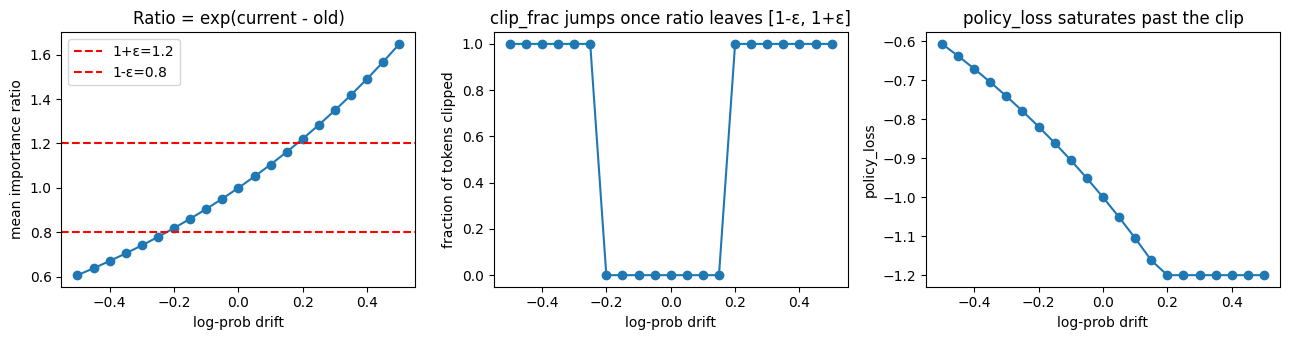

In [5]:
# Simulate a K=2 step: policy has moved +delta in log-prob space.
A = torch.tensor([1.0, 1.0, 1.0, 1.0])
drifts = torch.linspace(-0.5, 0.5, 21)
ratios, clip_fracs, policy_losses = [], [], []

for d in drifts:
    current_moved = current + float(d)
    _, m = compute_grpo_loss(current_moved, old, ref, A, mask, rl_cfg)
    ratios.append(m['ratio_mean'].item())
    clip_fracs.append(m['clip_frac'].item())
    policy_losses.append(m['policy_loss'].item())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(drifts, ratios, 'o-')
axes[0].axhline(1.0 + rl_cfg.clip_ratio, color='r', ls='--', label=f'1+ε={1+rl_cfg.clip_ratio}')
axes[0].axhline(1.0 - rl_cfg.clip_ratio, color='r', ls='--', label=f'1-ε={1-rl_cfg.clip_ratio}')
axes[0].set_xlabel('log-prob drift'); axes[0].set_ylabel('mean importance ratio'); axes[0].legend()
axes[0].set_title('Ratio = exp(current - old)')

axes[1].plot(drifts, clip_fracs, 'o-')
axes[1].set_xlabel('log-prob drift'); axes[1].set_ylabel('fraction of tokens clipped')
axes[1].set_title('clip_frac jumps once ratio leaves [1-ε, 1+ε]')

axes[2].plot(drifts, policy_losses, 'o-')
axes[2].set_xlabel('log-prob drift'); axes[2].set_ylabel('policy_loss')
axes[2].set_title('policy_loss saturates past the clip')
plt.tight_layout(); plt.show()

The middle plot is the headline: as soon as the policy drifts past ±0.2 in log-prob (= ratios outside [0.82, 1.22]), the clip kicks in and the surrogate stops rewarding further drift. That's what keeps mu_epochs > 1 stable. We default `mu_epochs=1` so the clip is never active — strictly correct K=1 code path.

## 5. The k3 KL estimator — non-negative by construction

The naive KL estimate $\mathrm{mean}(\log\pi_\theta - \log\pi_\mathrm{ref})$ is unbiased but high-variance — and worse, it can be NEGATIVE token-by-token (a single token where the policy assigns higher probability than the reference flips the sign). A negative KL inside the loss would push the policy AWAY from the reference, the opposite of what the anchor is supposed to do.

Schulman's k3 estimator $\mathrm{KL}_t = e^{\delta_t} - \delta_t - 1$ (where $\delta = \log\pi_\mathrm{ref} - \log\pi_\theta$) is:
- biased (slightly low),
- always non-negative (it's a Bregman divergence — equals 0 iff $\delta = 0$),
- lower variance than the naive estimator.

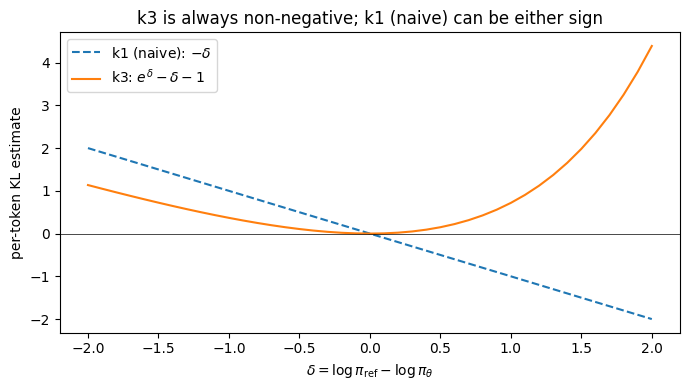

In [6]:
deltas = torch.linspace(-2.0, 2.0, 41)
k1_naive = -deltas                    # log(pi_theta) - log(pi_ref) = -delta
k3 = torch.exp(deltas) - deltas - 1   # the k3 estimator

plt.figure(figsize=(7, 4))
plt.plot(deltas, k1_naive, label='k1 (naive): $-\\delta$', linestyle='--')
plt.plot(deltas, k3, label='k3: $e^\\delta - \\delta - 1$')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('$\\delta = \\log\\pi_\\mathrm{ref} - \\log\\pi_\\theta$')
plt.ylabel('per-token KL estimate')
plt.title('k3 is always non-negative; k1 (naive) can be either sign')
plt.legend()
plt.tight_layout(); plt.show()

Notice k1 is linear in $\delta$ (sign depends on which way the policy drifted), whereas k3 is convex with minimum at $\delta=0$ — exactly what we want a regularizer to do.

## 6. End-to-end on a tiny Qwen3

Build a 1.4M-param random Qwen3 (no network needed), run the full pipeline:
1. `generate_rollout` — sample G completions per prompt, score them, build training tensors.
2. `train_step` — one forward + backward + optimizer step.
3. Verify the policy moved.

Reward will be 0 across the board (random tiny model can't satisfy the format), so all advantages will be 0 and only the KL term will contribute to the gradient. That's the correct degenerate-group behavior and the most common state at the very start of a real training run.

In [7]:
from transformers import Qwen3Config, Qwen3ForCausalLM
from rollout import generate_rollout
from loop import train_step

tiny_cfg = Qwen3Config(
    vocab_size=2048, hidden_size=64, num_hidden_layers=2,
    num_attention_heads=4, num_key_value_heads=2, intermediate_size=128,
    max_position_embeddings=256, tie_word_embeddings=True, use_cache=False,
)
torch.manual_seed(0)
policy = Qwen3ForCausalLM(tiny_cfg).float()
torch.manual_seed(1)
reference = Qwen3ForCausalLM(tiny_cfg).to(torch.bfloat16)
for p in reference.parameters(): p.requires_grad_(False)
reference.eval()

class FakeTok:
    pad_token_id = 0
    eos_token_id = 1
    def decode(self, ids, skip_special_tokens=False):
        return ' '.join(str(int(i)) for i in ids)
tok = FakeTok()

# Fake batch — 2 prompts of length 8 (left-padded), ground truths 4 and 7
batch = {
    'prompt_input_ids': torch.tensor([
        [0,0,0,5,6,7,8,9],
        [0,0,0,0,3,4,5,6],
    ]),
    'prompt_attention_mask': torch.tensor([
        [0,0,0,1,1,1,1,1],
        [0,0,0,0,1,1,1,1],
    ]),
    'ground_truth': [4, 7],
    'question': ['Q1', 'Q2'],
}
data_cfg = DataConfig(seq_len=8, prompts_per_step=2)
reward_cfg = RewardConfig()
rl_cfg2 = RLConfig(group_size=2, temperature=1.0, top_p=1.0, max_new_tokens=4,
                   kl_beta=0.04, clip_ratio=0.2, mu_epochs=1)

print('Generating rollout...')
rollout = generate_rollout(policy, reference, tok, batch, data_cfg, reward_cfg, rl_cfg2, device='cpu')
print(f'  input_ids shape: {tuple(rollout.input_ids.shape)}')
print(f'  advantages: {[round(a, 3) for a in rollout.advantages.tolist()]}')
print(f'  rewards: {[round(r.total, 3) for r in rollout.rewards]}')
print(f'  response_lengths: {rollout.response_lengths.tolist()}')
print(f'  example completion[0]: {rollout.completions_text[0]!r}')

print('\nTaking ONE gradient step...')
opt = torch.optim.AdamW(policy.parameters(), lr=1e-3)
stats = train_step(policy, opt, rollout, rl_cfg2, grad_clip=1.0, dtype='fp32', device='cpu')
print(f'  loss: {stats["loss"]:+.4f}  (= kl_loss when advantages are all 0)')
print(f'  policy_loss: {stats["policy_loss"]:+.4f}')
print(f'  kl_loss: {stats["kl_loss"]:+.4f}')
print(f'  ratio_mean: {stats["ratio_mean"]:.4f}  (expect 1.0 at K=1)')
print(f'  grad_norm: {stats["grad_norm"]:.3f}')

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating rollout...


  input_ids shape: (4, 11)
  advantages: [0.0, 0.0, 0.0, 0.0]
  rewards: [0.0, 0.0, 0.0, 0.0]
  response_lengths: [4, 4, 4, 4]
  example completion[0]: '668 1551 858 1794'

Taking ONE gradient step...
  loss: +0.0013  (= kl_loss when advantages are all 0)
  policy_loss: +0.0000
  kl_loss: +0.0013
  ratio_mean: 1.0000  (expect 1.0 at K=1)
  grad_norm: 0.055


## 7. The reward landscape — what a real training run looks like

On the canonical 1.7B / 300-step run, you'd expect the curves to roughly track this. (This is a hand-drawn idealization to set expectations — the real numbers will differ by problem, prompt phrasing, seed.)

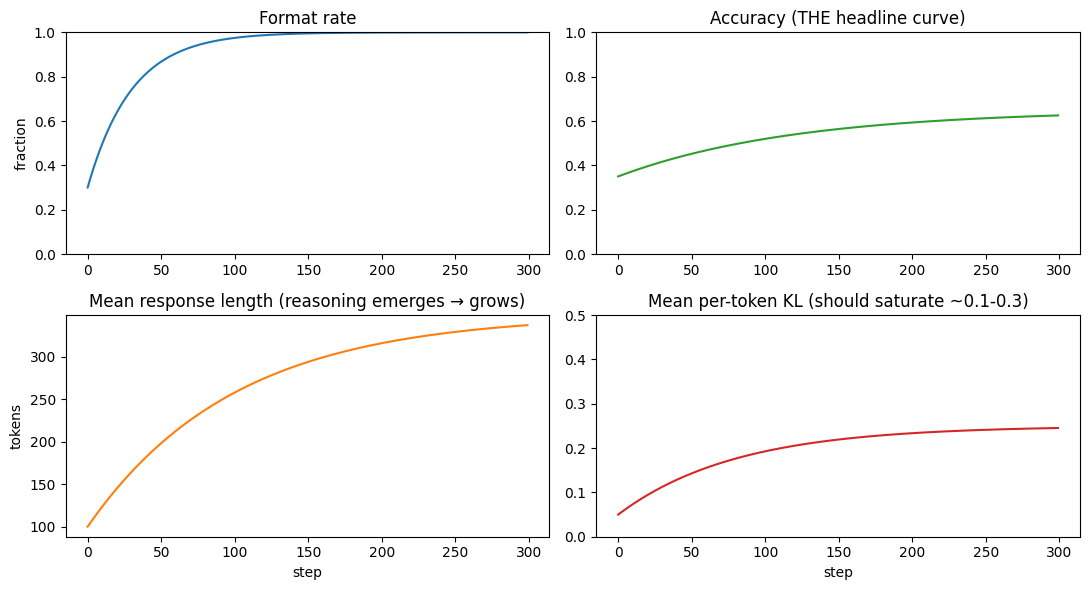

Reading the curves:
  - format_rate climbing first is your evidence the policy is responding to ANY signal.
  - accuracy is the real metric. If it plateaus before 50%, raise LR or check the verifier.
  - response length growing is the famous R1 "reasoning emergence" signature.
  - KL should saturate, not run away. If it climbs past 0.5, β is too low (mode collapse soon).


In [8]:
import numpy as np

steps = np.arange(300)
# Format saturates fast (training-wheels signal)
format_rate = 1 - np.exp(-steps / 30) * 0.7
# Accuracy lags and grows steadily
accuracy = 0.35 + 0.30 * (1 - np.exp(-steps / 120))
# Response length grows as reasoning emerges
response_len = 100 + 250 * (1 - np.exp(-steps / 100))
# KL anchor grows but bounded
kl = 0.05 + 0.20 * (1 - np.exp(-steps / 80))

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes[0,0].plot(steps, format_rate, color='tab:blue')
axes[0,0].set_title('Format rate'); axes[0,0].set_ylim(0, 1); axes[0,0].set_ylabel('fraction')
axes[0,1].plot(steps, accuracy, color='tab:green')
axes[0,1].set_title('Accuracy (THE headline curve)'); axes[0,1].set_ylim(0, 1)
axes[1,0].plot(steps, response_len, color='tab:orange')
axes[1,0].set_title('Mean response length (reasoning emerges → grows)')
axes[1,0].set_xlabel('step'); axes[1,0].set_ylabel('tokens')
axes[1,1].plot(steps, kl, color='tab:red')
axes[1,1].set_title('Mean per-token KL (should saturate ~0.1-0.3)')
axes[1,1].set_xlabel('step'); axes[1,1].set_ylim(0, 0.5)
plt.tight_layout(); plt.show()

print('Reading the curves:')
print('  - format_rate climbing first is your evidence the policy is responding to ANY signal.')
print('  - accuracy is the real metric. If it plateaus before 50%, raise LR or check the verifier.')
print('  - response length growing is the famous R1 "reasoning emergence" signature.')
print('  - KL should saturate, not run away. If it climbs past 0.5, β is too low (mode collapse soon).')

## 8. Memory accounting (Qwen3-1.7B)

GRPO is the most memory-hungry post-training stage: two models + rollout activations + AdamW. Activation checkpointing is mandatory.

In [9]:
N_PARAMS = 1.7e9
GB = 1024**3

policy_master = 4 * N_PARAMS
policy_compute = 2 * N_PARAMS
policy_grads = 2 * N_PARAMS
policy_opt = 8 * N_PARAMS
ref_bf16 = 2 * N_PARAMS
rollout_kv = 6e9          # ~6 GB at G=8, max_new=512
activations_ac = 8e9      # ~8 GB with AC at seq=1024+512, batch=2

rows = [
    ('Policy: master weights (FP32)', policy_master),
    ('Policy: compute weights (BF16)', policy_compute),
    ('Policy: gradients (BF16)', policy_grads),
    ('Policy: AdamW state (FP32 m+v)', policy_opt),
    ('Reference: BF16 only, no grad', ref_bf16),
    ('Rollout KV cache (G·max_new)', rollout_kv),
    ('Activations (AC on)', activations_ac),
]
total = sum(b for _, b in rows)
print(f'{"component":<40} {"GB":>8}')
print('-' * 50)
for name, b in rows:
    print(f'  {name:<38} {b/GB:>8.2f}')
print('-' * 50)
print(f'  {"TOTAL per rank":<38} {total/GB:>8.2f}')
print()
print(f'  A100-80GB: {total/GB:.1f} / 80 = {100*total/GB/80:.0f}% utilization (fits comfortably)')
print(f'  Without AC: activations would be ~16x larger -> {(total - activations_ac + activations_ac*16)/GB:.0f} GB (OOM)')

component                                      GB
--------------------------------------------------
  Policy: master weights (FP32)              6.33
  Policy: compute weights (BF16)             3.17
  Policy: gradients (BF16)                   3.17
  Policy: AdamW state (FP32 m+v)            12.67
  Reference: BF16 only, no grad              3.17
  Rollout KV cache (G·max_new)               5.59
  Activations (AC on)                        7.45
--------------------------------------------------
  TOTAL per rank                            41.54

  A100-80GB: 41.5 / 80 = 52% utilization (fits comfortably)
  Without AC: activations would be ~16x larger -> 153 GB (OOM)


## Recap

You've seen the five new pieces this module adds on top of Module 16's DPO machinery:

1. **Verifiable reward** — a pure function (`compute_rewards`) replaces the reward model.
2. **On-policy rollouts** — `generate_rollout` samples G completions per prompt and scores them.
3. **Group-relative advantages** — within-prompt z-scoring replaces a learned value head.
4. **PPO clip + per-token k3 KL** — clipped surrogate keeps mu_epochs > 1 stable, KL anchors against drift.
5. **Two models + rollout cache** — same memory pattern as DPO plus the KV cache during generation.

The math, once and for all:

$$L_t = -\min(\rho_t A_i,\ \mathrm{clip}(\rho_t, 1-\varepsilon, 1+\varepsilon) A_i) + \beta \cdot (e^{\delta_t} - \delta_t - 1)$$

Now scale up to the canonical run:

```bash
torchrun --standalone --nproc_per_node=1 train.py --config=configs/grpo_qwen3_1.7b.yaml
```